# ANALYSIS OF CLIMATE CHANGE AND CO2 EMISSIONS (1960–2050)

Analyze and model the relationship between CO₂ emissions and temperature change from 1960–2010, and forecast trends till 2050 using linear regression. Univariate and multivariate linear regression models are used to model temperature change based on year and CO₂ emissions. The regression models were then used to forecast temperature change up to 2050 by extrapolating CO₂ emissions using a linear trend.

In [80]:
from google.colab import files
uploaded = files.upload()

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Reading the csv file from pandas read_csv function.
co2_df = pd.read_csv('global_co2.csv')
co2_df.tail()

Saving annual_temp.csv to annual_temp (3).csv
Saving global_co2.csv to global_co2 (3).csv


,Year,Total,Gas Fuel,Liquid Fuel,Solid Fuel,Cement,Gas Flaring,Per Capita
255,2006,8370,1525,3089,3339,356,61,1.27
256,2007,8566,1572,3081,3464,382,68,1.28
257,2008,8783,1631,3122,3571,388,71,1.30
258,2009,8740,1585,3056,3620,413,66,1.28
259,2010,9167,1702,3114,3842,450,59,1.33


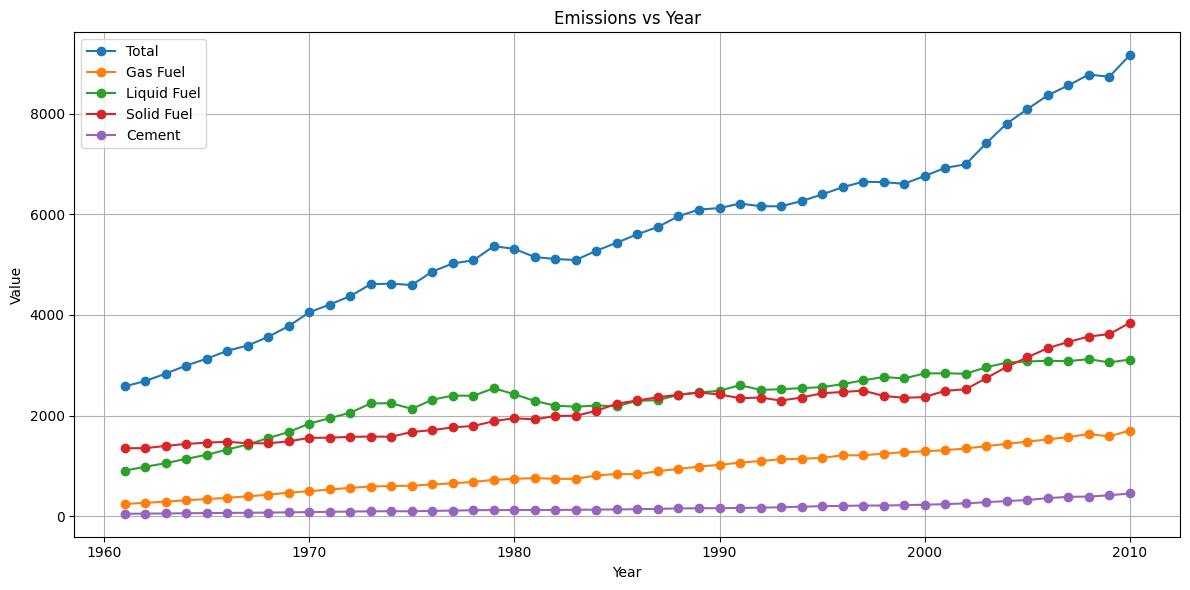

In [81]:
# Consider the data from 1960 onwards
co2_df = co2_df[co2_df.Year > 1960]
cols = ['Total', 'Gas Fuel', 'Liquid Fuel', 'Solid Fuel', 'Cement']
plt.figure(figsize=(12, 6))
for col in cols:
    plt.plot(co2_df['Year'], co2_df[col], marker='o', label=col)

# Plotting emissions vs year
plt.xlabel('Year')
plt.ylabel('Value')
plt.title('Emissions vs Year')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [82]:
# Considering only first two columns
co2_df = co2_df.drop(columns=co2_df.columns[2:])
co2_df.columns = ['Year','CO2_emissions']   # renaming them
co2_df = co2_df.reset_index(drop=True)   # reset index to 0
co2_df.tail()

,Year,CO2_emissions
45,2006,8370
46,2007,8566
47,2008,8783
48,2009,8740
49,2010,9167


In [83]:
# Load the global tempeerature dataset
temp_df = pd.read_csv('annual_temp.csv')
temp_df.head()

,Source,Year,Mean
0,GCAG,2015,0.8990
1,GISTEMP,2015,0.8700
2,GCAG,2014,0.7402
3,GISTEMP,2014,0.7500
4,GCAG,2013,0.6687


In [84]:
# Consiering the data from only one source and then drop that column
temp_df = temp_df[temp_df['Source'] != 'GISTEMP'].copy()
temp_df.drop('Source', axis=1, inplace=True)

# Consider the data between 1960 to 2010
temp_df = temp_df[(temp_df.Year > 1960) & (temp_df.Year < 2011)]
# inverting the columns to sort in increasing order
temp_df = temp_df.reindex(index=temp_df.index[::-1])
temp_df.columns = ['Year','Temp_change']     # renaming column names
temp_df = temp_df.reset_index(drop=True)
temp_df.tail()

,Year,Temp_change
45,2006,0.6139
46,2007,0.6113
47,2008,0.5415
48,2009,0.6354
49,2010,0.7008


In [85]:
# Concatenating 2 datasets with year as common column
df = pd.concat([co2_df,temp_df.Temp_change], axis=1)
df.head()

,Year,CO2_emissions,Temp_change
0,1961,2580,0.0818
1,1962,2686,0.0924
2,1963,2833,0.1100
3,1964,2995,-0.1461
4,1965,3130,-0.0752


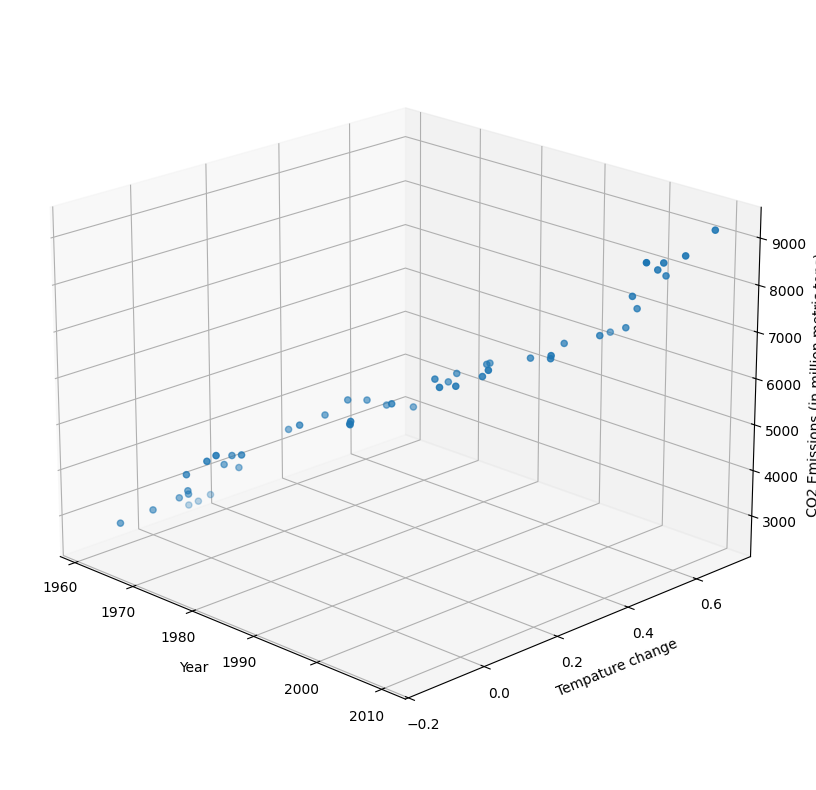

In [86]:
# Plotting in 3D
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure()
fig.set_size_inches(12, 10)
ax = fig.add_subplot(111, projection='3d')
ax.scatter(xs= df['Year'],ys=df['Temp_change'],zs = df['CO2_emissions'])
ax.set_ylabel('Tempature change');
ax.set_xlabel('Year');
ax.set_zlabel('CO2 Emissions (in million metric tons)')
ax.view_init(20, -45)     # for setting the appropiate view

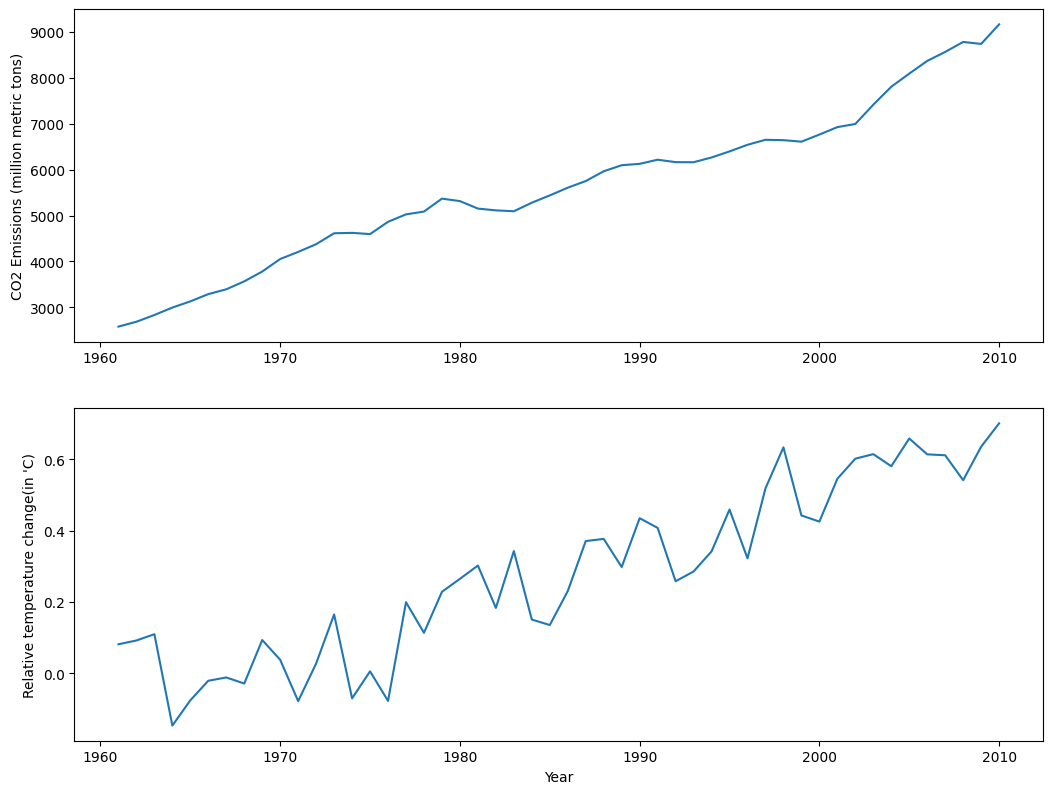

In [87]:
# 2D plots
fig = plt.figure()
fig.set_size_inches(12.5, 9.5)
plt.subplot(2, 1, 1)
plt.plot(df['Year'],df['CO2_emissions'])
plt.ylabel('CO2 Emissions (million metric tons)')

plt.subplot(2, 1, 2)
plt.plot(df['Year'],df['Temp_change'])
plt.xlabel('Year')
plt.ylabel("Relative temperature change(in 'C)")
plt.show()

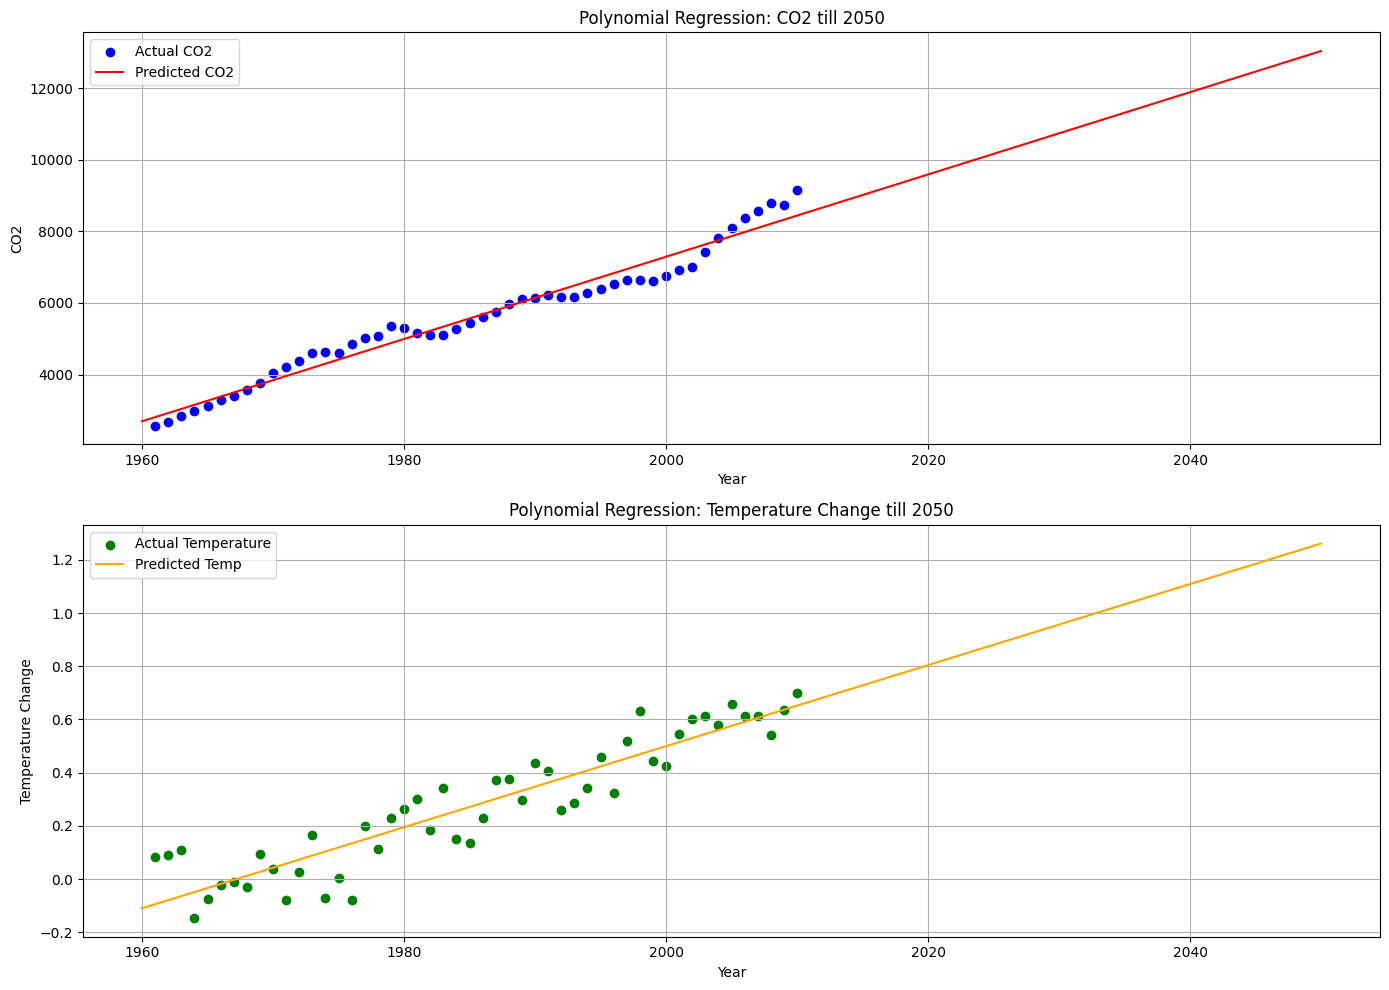

In [88]:
def predict_polynomial(x_range, w_opt, m):
    X = np.vander(x_range, m + 1, increasing=False)
    return X @ w_opt

def polynomial_fit(x_range, y_range, m, lamda):
    # Step 1: Build the design matrix (Vandermonde matrix)
    X = np.vander(x_range, m + 1, increasing=False)
    # Solve for w_opt using least squares: w = (XᵀX)^(-1) Xᵀy
    w_opt = np.linalg.inv(X.T @ X) @ X.T @ y_range
    return w_opt

# Original data
X_years = df['Year'].values
y_co2 = df['CO2_emissions'].values
y_temp = df['Temp_change'].values

# Future years
years_future = np.arange(1960, 2051)

deg = 1 # polynomial degree
lamda=1e-3 # regularisation constant
w_co2 = polynomial_fit(X_years, y_co2, deg, lamda)
w_temp = polynomial_fit(X_years, y_temp, deg, lamda)

# Predictions
co2_pred = predict_polynomial(years_future, w_co2, deg)
temp_pred = predict_polynomial(years_future, w_temp, deg)

plt.figure(figsize=(14, 10))
# CO2 Plot
plt.subplot(2, 1, 1)
plt.scatter(X_years, y_co2, color='blue', label='Actual CO2')
plt.plot(years_future, co2_pred, color='red', label='Predicted CO2')
plt.title("Polynomial Regression: CO2 till 2050")
plt.xlabel("Year")
plt.ylabel("CO2")
plt.legend()
plt.grid(True)

# Temperature Plot
plt.subplot(2, 1, 2)
plt.scatter(X_years, y_temp, color='green', label='Actual Temperature')
plt.plot(years_future, temp_pred, color='orange', label='Predicted Temp')
plt.title("Polynomial Regression: Temperature Change till 2050")
plt.xlabel("Year")
plt.ylabel("Temperature Change")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


In [89]:
# Error predictions
def PolynomialPred_Error(w_est, X, Y):
    # Predict using polynomial coefficients
    Y_pred = np.polyval(w_est, X)
    # Calculate Mean Squared Error (MSE)
    error = np.mean((Y_pred - Y) ** 2)
    return error

error_CO2_pred=PolynomialPred_Error(w_co2, X_years, y_co2)
error_tempchange_pred=PolynomialPred_Error(w_temp, X_years, y_temp)
print(error_CO2_pred)
print(error_tempchange_pred)

97770.69371044425
0.008347197447356586


[-3.68443199e+01  1.87848884e-02 -3.09608146e-05]


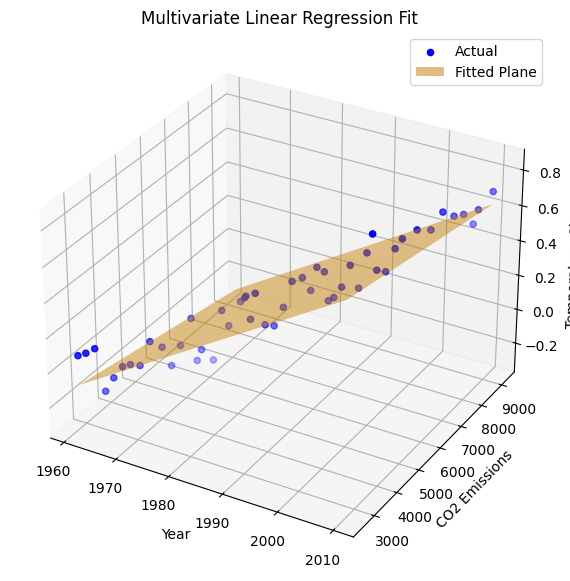

In [90]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Explicit multivariate fit function
def multivariate_fit(X, y):
    N = X.shape[0]
    X_aug = np.hstack([np.ones((N, 1)), X])  # Add intercept column
    w_opt = np.linalg.inv(X_aug.T @ X_aug) @ X_aug.T @ y
    return w_opt

# Explicit prediction function
def predict_multivariate(X, w_opt):
    N = X.shape[0]
    X_aug = np.hstack([np.ones((N, 1)), X])
    return X_aug @ w_opt

# Preparing data
X = df[['Year', 'CO2_emissions']].values
y = df['Temp_change'].values
w_opt = multivariate_fit(X, y)
print(w_opt)

# Predict on training data
y_pred = predict_multivariate(X, w_opt)
fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X[:,0], X[:,1], y, color='blue', label='Actual')

# Creating grid to plot regression plane
year_grid = np.linspace(X[:,0].min(), X[:,0].max(), 30)
co2_grid = np.linspace(X[:,1].min(), X[:,1].max(), 30)
year_grid, co2_grid = np.meshgrid(year_grid, co2_grid)
grid_points = np.c_[year_grid.ravel(), co2_grid.ravel()]

temp_pred_grid = predict_multivariate(grid_points, w_opt)
temp_pred_grid = temp_pred_grid.reshape(year_grid.shape)

# Plotting
ax.plot_surface(year_grid, co2_grid, temp_pred_grid, color='orange', alpha=0.5, label='Fitted Plane')
ax.set_xlabel('Year')
ax.set_ylabel('CO2 Emissions')
ax.set_zlabel('Temperature Change')
ax.set_title('Multivariate Linear Regression Fit')
plt.legend()
plt.show()
